# SD11 Football Scouting — Data Visualization
Connects to the AWS RDS PostgreSQL database and visualizes what has been collected.

In [1]:
!pip3 install psycopg2-binary pandas matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [2]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

## 1. Connection
Upload your `.env` file to Colab (Files panel → upload), then run this cell.
Uses the same `env.load()` / `env.get()` pattern as `srcRaw/main.py`.

In [3]:
# ── mirrors srcRaw/env.py ──────────────────────────────────────
_env_vars = {}

def env_load(path=".env"):
    for line in open(path):
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        key, value = line.split("=", 1)
        _env_vars[key.strip()] = value.strip().strip('"')

def env_get(key):
    return _env_vars.get(key)
# ───────────────────────────────────────────────────────────────

env_load()

envHost     = env_get("T_DB_HOST")
envPort     = env_get("T_DB_PORT")
envDBName   = env_get("T_DB_NAME")
envPassword = env_get("T_DB_PASSWORD")

conn = psycopg2.connect(
    host=envHost, port=envPort, dbname=envDBName,
    user="postgres", password=envPassword, sslmode="require", connect_timeout=10
)
print("Connected.")

def q(sql, params=None):
    return pd.read_sql(sql, conn, params=params)

Connected.


## 2. Coverage Overview
How many rows exist in each table?

/var/folders/d8/thlb33gs6m703zd_wdqqkmlr0000gn/T/ipykernel_8006/4156287225.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


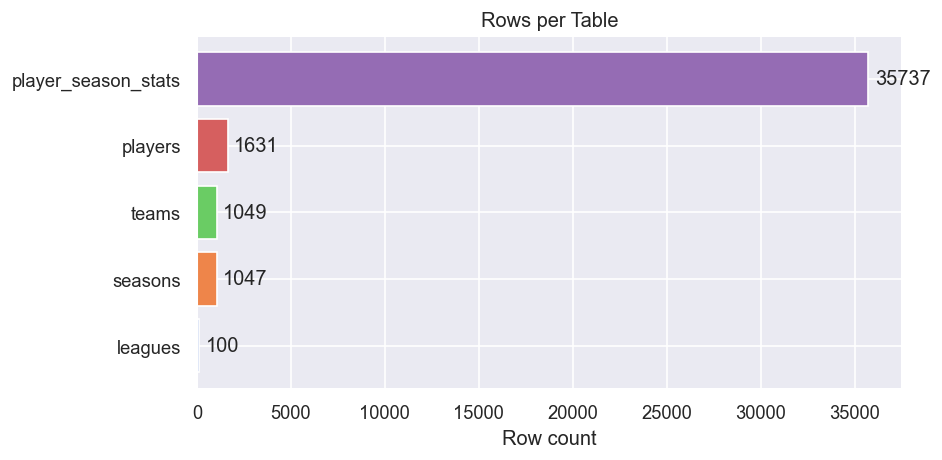

              table  rows
            leagues   100
            seasons  1047
              teams  1049
            players  1631
player_season_stats 35737


In [4]:
tables = ["leagues", "seasons", "teams", "players", "player_season_stats"]
counts = {t: q(f"SELECT COUNT(*) AS n FROM {t}").iloc[0]["n"] for t in tables}
counts_df = pd.DataFrame({"table": list(counts.keys()), "rows": list(counts.values())})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(counts_df["table"], counts_df["rows"], color=sns.color_palette("muted"))
ax.bar_label(bars, padding=4)
ax.set_xlabel("Row count")
ax.set_title("Rows per Table")
plt.tight_layout()
plt.show()

print(counts_df.to_string(index=False))

## 3. Leagues & Seasons

In [5]:
leagues = q("SELECT league_id, name FROM leagues ORDER BY name")
print("Leagues collected:")
print(leagues.to_string(index=False))

Leagues collected:
 league_id                         name
       244                       1. HNL
       603                       1. Lig
        85                2. Bundesliga
       181           Admiral Bundesliga
      1085   AFC Champions League Elite
      1088     AFC Champions League Two
      1356                 A-League Men
       573                  Allsvenskan
      1434                 Atlantic Cup
       860                   Botola Pro
        82                   Bundesliga
      1107         CAF Champions League
        27                  Carabao Cup
       211        Challenger Pro League
         9                 Championship
         2             Champions League
       262                  Chance Liga
      3497              Club Friendlies
      1101            Club Friendlies 1
      2450            Club Friendlies 2
      2451            Club Friendlies 3
      2452            Club Friendlies 4
        23             Community Shield
      1658         Co

/var/folders/d8/thlb33gs6m703zd_wdqqkmlr0000gn/T/ipykernel_8006/4156287225.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


In [ ]:
seasons_per_league = q("""
    SELECT l.name AS league, COUNT(s.season_id) AS seasons
    FROM leagues l
    LEFT JOIN seasons s USING (league_id)
    GROUP BY l.name
    ORDER BY seasons DESC
""")

fig, ax = plt.subplots(figsize=(8, max(3, len(seasons_per_league) * 0.5)))
sns.barplot(data=seasons_per_league, y="league", x="seasons", ax=ax, palette="muted")
ax.set_title("Seasons Collected per League")
ax.set_xlabel("Seasons")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. Teams per League

In [ ]:
teams_per_league = q("""
    SELECT l.name AS league, COUNT(t.team_id) AS teams
    FROM leagues l
    LEFT JOIN teams t USING (league_id)
    GROUP BY l.name
    ORDER BY teams DESC
""")

fig, ax = plt.subplots(figsize=(8, max(3, len(teams_per_league) * 0.5)))
sns.barplot(data=teams_per_league, y="league", x="teams", ax=ax, palette="muted")
ax.set_title("Teams per League")
ax.set_xlabel("Teams")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Players per League

In [ ]:
players_per_league = q("""
    SELECT l.name AS league, COUNT(DISTINCT pss.player_id) AS players
    FROM leagues l
    JOIN seasons s USING (league_id)
    JOIN player_season_stats pss USING (season_id)
    GROUP BY l.name
    ORDER BY players DESC
""")

fig, ax = plt.subplots(figsize=(8, max(3, len(players_per_league) * 0.5)))
sns.barplot(data=players_per_league, y="league", x="players", ax=ax, palette="muted")
ax.set_title("Unique Players with Stats per League")
ax.set_xlabel("Players")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Stats Completeness
What fraction of `player_season_stats` rows have non-null values for each stat column?

In [ ]:
stat_cols = [
    "appearances", "minutes_played", "goals", "shots_total", "shots_on_target",
    "passes", "accurate_passes", "accurate_passes_percentage", "key_passes",
    "dribble_attempts", "successful_dribbles", "tackles", "interceptions",
    "clearances", "total_duels", "duels_won", "aerials_won", "fouls",
    "dispossessed", "total_crosses", "accurate_crosses", "shots_blocked",
    "sub_in", "sub_out", "hit_woodwork", "redcards", "goals_conceded",
    "fouls_drawn", "dribbled_past", "cleansheets", "team_wins", "team_draws",
    "team_lost", "lineups", "bench", "avg_points", "crosses_blocked"
]

count_exprs = ", ".join(f"COUNT({c}) AS {c}" for c in stat_cols)
raw = q(f"SELECT COUNT(*) AS total, {count_exprs} FROM player_season_stats")
total = raw["total"].iloc[0]
fill_rate = (raw[stat_cols].iloc[0] / total * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(stat_cols) * 0.35))
colors = ["#e74c3c" if v < 50 else "#2ecc71" for v in fill_rate.values]
fill_rate.plot.barh(ax=ax, color=colors)
ax.axvline(50, color="white", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlim(0, 105)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title(f"Column Fill Rate  (n={total:,} rows)")
ax.set_xlabel("% non-null")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 7. Top Goal Scorers (all time)

In [ ]:
top_scorers = q("""
    SELECT
        p.display_name AS player,
        SUM(pss.goals) AS total_goals,
        SUM(pss.appearances) AS appearances
    FROM player_season_stats pss
    JOIN players p USING (player_id)
    GROUP BY p.display_name
    ORDER BY total_goals DESC NULLS LAST
    LIMIT 20
""")

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_scorers, y="player", x="total_goals", ax=ax, palette="flare")
ax.set_title("Top 20 Goal Scorers (across all collected seasons)")
ax.set_xlabel("Goals")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8. Minutes Played Distribution

In [ ]:
minutes = q("""
    SELECT pss.minutes_played, l.name AS league
    FROM player_season_stats pss
    JOIN seasons s USING (season_id)
    JOIN leagues l USING (league_id)
    WHERE pss.minutes_played IS NOT NULL AND pss.minutes_played > 0
""")

fig, ax = plt.subplots(figsize=(9, 4))
for league, grp in minutes.groupby("league"):
    grp["minutes_played"].plot.kde(ax=ax, label=league, linewidth=1.8)
ax.set_xlim(left=0)
ax.set_title("Minutes Played Distribution by League")
ax.set_xlabel("Minutes played (season)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Goals vs Minutes Played (scatter)

In [ ]:
gvm = q("""
    SELECT
        pss.minutes_played,
        pss.goals,
        l.name AS league
    FROM player_season_stats pss
    JOIN seasons s USING (season_id)
    JOIN leagues l USING (league_id)
    WHERE pss.minutes_played > 90 AND pss.goals IS NOT NULL
""")

fig, ax = plt.subplots(figsize=(9, 5))
for league, grp in gvm.groupby("league"):
    ax.scatter(grp["minutes_played"], grp["goals"], alpha=0.35, s=12, label=league)
ax.set_title("Goals vs Minutes Played per Player-Season")
ax.set_xlabel("Minutes played")
ax.set_ylabel("Goals")
ax.legend(fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

## 10. Player Nationality Breakdown

In [ ]:
nationalities = q("""
    SELECT country, COUNT(*) AS players
    FROM players
    WHERE country IS NOT NULL
    GROUP BY country
    ORDER BY players DESC
    LIMIT 20
""")

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=nationalities, y="country", x="players", ax=ax, palette="muted")
ax.set_title("Top 20 Player Nationalities")
ax.set_xlabel("Players")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 11. Do we have 5 "full" leagues? — Null count per column

/var/folders/d8/thlb33gs6m703zd_wdqqkmlr0000gn/T/ipykernel_8006/4156287225.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)
/var/folders/d8/thlb33gs6m703zd_wdqqkmlr0000gn/T/ipykernel_8006/4156287225.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)
/var/folders/d8/thlb33gs6m703zd_wdqqkmlr0000gn/T/ipykernel_8006/4156287225.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)
/var/folde

Leagues with >= 100 stat rows: 40

Top 5 full leagues: ['Serie A', 'Copa do Brasil', 'Club Friendlies 3', 'Premier League', 'FA Cup']



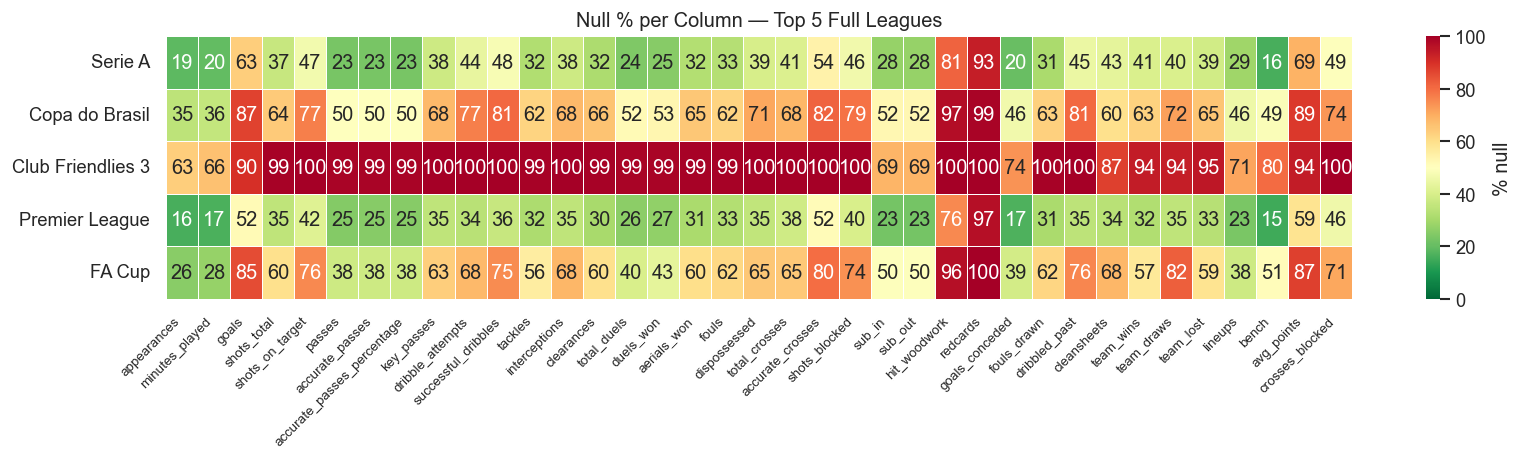


Raw null counts:
                   total_rows  appearances  minutes_played  goals  shots_total  shots_on_target  passes  accurate_passes  accurate_passes_percentage  key_passes  dribble_attempts  successful_dribbles  tackles  interceptions  clearances  total_duels  duels_won  aerials_won  fouls  dispossessed  total_crosses  accurate_crosses  shots_blocked  sub_in  sub_out  hit_woodwork  redcards  goals_conceded  fouls_drawn  dribbled_past  cleansheets  team_wins  team_draws  team_lost  lineups  bench  avg_points  crosses_blocked
league                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [6]:
stat_cols = [
    "appearances", "minutes_played", "goals", "shots_total", "shots_on_target",
    "passes", "accurate_passes", "accurate_passes_percentage", "key_passes",
    "dribble_attempts", "successful_dribbles", "tackles", "interceptions",
    "clearances", "total_duels", "duels_won", "aerials_won", "fouls",
    "dispossessed", "total_crosses", "accurate_crosses", "shots_blocked",
    "sub_in", "sub_out", "hit_woodwork", "redcards", "goals_conceded",
    "fouls_drawn", "dribbled_past", "cleansheets", "team_wins", "team_draws",
    "team_lost", "lineups", "bench", "avg_points", "crosses_blocked",
]

# A league is "full" if it has at least 100 rows in player_season_stats
FULL_THRESHOLD = 100

league_row_counts = q(f"""
    SELECT l.name AS league, COUNT(*) AS total_rows
    FROM player_season_stats pss
    JOIN seasons s USING (season_id)
    JOIN leagues l USING (league_id)
    GROUP BY l.name
    HAVING COUNT(*) >= {FULL_THRESHOLD}
    ORDER BY total_rows DESC
""")

full_leagues = league_row_counts["league"].tolist()
print(f"Leagues with >= {FULL_THRESHOLD} stat rows: {len(full_leagues)}")

if len(full_leagues) < 5:
    print(f"Only {len(full_leagues)} full league(s) found — need at least 5.")
else:
    top5 = full_leagues[:5]
    print(f"\nTop 5 full leagues: {top5}\n")

    null_exprs = "\n        , ".join(
        f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS {c}" for c in stat_cols
    )

    rows = []
    for league in top5:
        df = q(f"""
            SELECT
                COUNT(*) AS total_rows
                , {null_exprs}
            FROM player_season_stats pss
            JOIN seasons s USING (season_id)
            JOIN leagues l USING (league_id)
            WHERE l.name = %(league)s
        """, params={"league": league})
        total = df["total_rows"].iloc[0]
        null_counts = df[stat_cols].iloc[0]
        row = {"league": league, "total_rows": total}
        row.update(null_counts.to_dict())
        rows.append(row)

    null_df = pd.DataFrame(rows).set_index("league")

    # heatmap: nulls as % of each league's row count
    totals = null_df["total_rows"]
    pct_df = null_df[stat_cols].div(totals, axis=0) * 100

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(
        pct_df,
        annot=True, fmt=".0f", linewidths=0.4,
        cmap="RdYlGn_r", vmin=0, vmax=100,
        ax=ax, cbar_kws={"label": "% null"}
    )
    ax.set_title("Null % per Column — Top 5 Full Leagues")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nRaw null counts:")
    print(null_df[["total_rows"] + stat_cols].to_string())

In [ ]:
conn.close()
print("Connection closed.")